In [1]:
# ---- Core imports ----
import os, io, time, math, random, zipfile, urllib.request, glob, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print(e)


TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ---- Working directories ----
WORK_DIR = "/kaggle/working"
DATA_DIR = os.path.join(WORK_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print("Working directory:", os.getcwd())


Working directory: /kaggle/working


In [3]:
# ---- Download and unzip the official UCI HAR dataset ----
UCI_HAR_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = os.path.join(DATA_DIR, "UCI_HAR_Dataset.zip")
EXTRACT_DIR = os.path.join(DATA_DIR, "UCI_HAR_Dataset")

if not os.path.exists(EXTRACT_DIR):
    print("Downloading UCI HAR dataset ...")
    try:
        urllib.request.urlretrieve(UCI_HAR_URL, ZIP_PATH)
    except Exception as e:
        # Fallback mirror (same file, hosted for reliability on Kaggle's network)
        print("Primary source failed, trying mirror ...", e)
        MIRROR_URL = "https://raw.githubusercontent.com/jmxjm/UCI-HAR-Dataset/master/UCI%20HAR%20Dataset.zip"
        urllib.request.urlretrieve(MIRROR_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Dataset already present.")

HAR_ROOT = os.path.join(DATA_DIR, "UCI HAR Dataset")
print(os.listdir(HAR_ROOT))


Extraction complete.
['test', 'train', '.DS_Store', 'activity_labels.txt', 'README.txt', 'features.txt', 'features_info.txt']


In [4]:
# ---- Load raw inertial signal files (9 channels) for a given split ----
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_MAP = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING"
}

def load_split(split):
    """split = 'train' or 'test'. Returns X:(N,128,9), y:(N,) with labels 0..5"""
    sig_dir = os.path.join(HAR_ROOT, split, "Inertial Signals")
    channels = []
    for name in SIGNAL_NAMES:
        fpath = os.path.join(sig_dir, f"{name}_{split}.txt")
        arr = np.loadtxt(fpath)              # (N, 128)
        channels.append(arr)
    X = np.stack(channels, axis=-1)          # (N, 128, 9)
    y = np.loadtxt(os.path.join(HAR_ROOT, split, f"y_{split}.txt")).astype(int) - 1  # 0..5
    return X, y

X_train_full, y_train_full = load_split("train")
X_test_full, y_test_full   = load_split("test")

# Pool everything: preprocessing + our own train/val/test protocol will be applied afterwards
X_pool = np.concatenate([X_train_full, X_test_full], axis=0)
y_pool = np.concatenate([y_train_full, y_test_full], axis=0)
print("Full pooled raw data:", X_pool.shape, y_pool.shape)


Full pooled raw data: (10299, 128, 9) (10299,)


In [5]:
# ---- Recommended laboratory subset: balanced ~3000 windows (500 / class) ----
PER_CLASS = 500
rng = np.random.default_rng(SEED)

idx_selected = []
for c in range(6):
    class_idx = np.where(y_pool == c)[0]
    chosen = rng.choice(class_idx, size=min(PER_CLASS, len(class_idx)), replace=False)
    idx_selected.append(chosen)
idx_selected = np.concatenate(idx_selected)
rng.shuffle(idx_selected)

X_sub = X_pool[idx_selected]
y_sub = y_pool[idx_selected]
print("Recommended subset shape:", X_sub.shape, y_sub.shape)
print("Class distribution:", {ACTIVITY_MAP[c+1]: int((y_sub==c).sum()) for c in range(6)})


Recommended subset shape: (3000, 128, 9) (3000,)
Class distribution: {'WALKING': 500, 'WALKING_UPSTAIRS': 500, 'WALKING_DOWNSTAIRS': 500, 'SITTING': 500, 'STANDING': 500, 'LAYING': 500}


In [6]:
# ---- Train / Validation / Test split: 70% / 15% / 15% ----
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, random_state=SEED, stratify=y_sub)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# ---- Normalize using statistics computed ONLY from the training data ----
n_train, T, F = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F))

def normalize(X):
    Ns, Ts, Fs = X.shape
    Xn = scaler.transform(X.reshape(-1, Fs)).reshape(Ns, Ts, Fs)
    return Xn

X_train_n = normalize(X_train)
X_val_n   = normalize(X_val)
X_test_n  = normalize(X_test)

N_train, N_val, N_test = X_train_n.shape[0], X_val_n.shape[0], X_test_n.shape[0]
NUM_CLASSES = 6
SEQ_LEN = 128
NUM_FEATURES = 9

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {NUM_FEATURES}")
print(f"Sequence length: {SEQ_LEN}")


Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


In [7]:
# ---- Verify class distribution across splits ----
for name, y_ in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = {ACTIVITY_MAP[c+1]: int((y_ == c).sum()) for c in range(6)}
    print(name, counts)


train {'WALKING': 350, 'WALKING_UPSTAIRS': 350, 'WALKING_DOWNSTAIRS': 350, 'SITTING': 350, 'STANDING': 350, 'LAYING': 350}
val {'WALKING': 75, 'WALKING_UPSTAIRS': 75, 'WALKING_DOWNSTAIRS': 75, 'SITTING': 75, 'STANDING': 75, 'LAYING': 75}
test {'WALKING': 75, 'WALKING_UPSTAIRS': 75, 'WALKING_DOWNSTAIRS': 75, 'SITTING': 75, 'STANDING': 75, 'LAYING': 75}


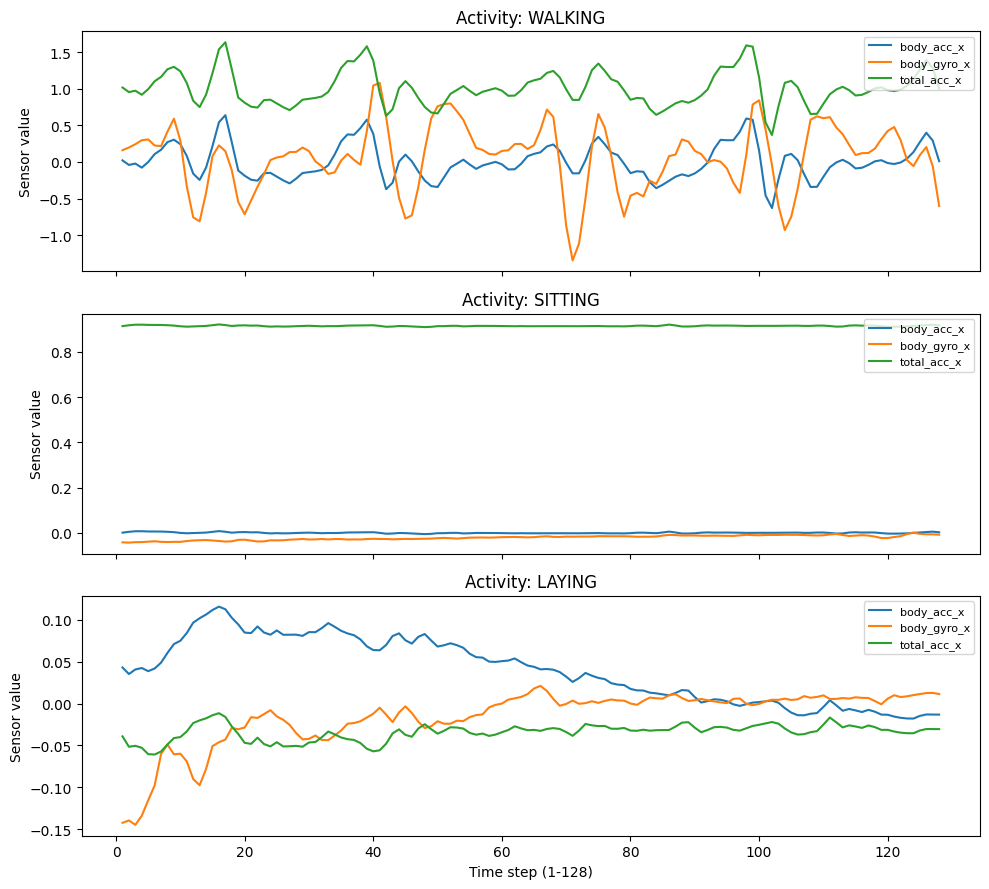

In [8]:
CHANNELS_TO_PLOT = [0, 3, 6]   # body_acc_x, body_gyro_x, total_acc_x
CHANNEL_LABELS = ["body_acc_x", "body_gyro_x", "total_acc_x"]
CLASSES_TO_PLOT = [0, 3, 5]     # WALKING, SITTING, LAYING (contrasting dynamic vs static)

fig, axes = plt.subplots(len(CLASSES_TO_PLOT), 1, figsize=(10, 9), sharex=True)
for ax, c in zip(axes, CLASSES_TO_PLOT):
    sample_idx = np.where(y_train == c)[0][0]
    seq = X_train[sample_idx]  # raw (un-normalized) for interpretability
    for ch, lbl in zip(CHANNELS_TO_PLOT, CHANNEL_LABELS):
        ax.plot(range(1, SEQ_LEN + 1), seq[:, ch], label=lbl)
    ax.set_title(f"Activity: {ACTIVITY_MAP[c+1]}")
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.savefig("plot1_sensor_signals.png", dpi=120)
plt.show()


In [9]:
# ---- Manual BPTT numerical exercise ----
x = [0.5, 0.7, 0.2]
h_prev = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

h_values = []
for t, xt in enumerate(x, start=1):
    z = Wx * xt + Wh * h_prev + b
    h_t = math.tanh(z)
    h_values.append(h_t)
    print(f"h{t} = tanh({Wx}*{xt} + {Wh}*{h_prev:.6f} + {b}) = tanh({z:.6f}) = {h_t:.6f}")
    h_prev = h_t

print("\nFinal hidden states:", [round(v, 6) for v in h_values])


h1 = tanh(0.5*0.5 + 0.8*0.000000 + 0.1) = tanh(0.350000) = 0.336376
h2 = tanh(0.5*0.7 + 0.8*0.336376 + 0.1) = tanh(0.719100) = 0.616352
h3 = tanh(0.5*0.2 + 0.8*0.616352 + 0.1) = tanh(0.693081) = 0.599958

Final hidden states: [0.336376, 0.616352, 0.599958]


In [10]:
RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30

def build_model(recurrent_type="SimpleRNN", units=RECURRENT_UNITS,
                 seq_len=SEQ_LEN, num_features=NUM_FEATURES, num_classes=NUM_CLASSES,
                 extra_layer=False, bidirectional=False):
    """Builds the classifier described in Section 9/10/11/12 of the handout.
    extra_layer / bidirectional are used later for Additional Exercise 3 and 4."""
    inputs = layers.Input(shape=(seq_len, num_features))

    RecLayer = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[recurrent_type]

    x = inputs
    if extra_layer:
        rec1 = RecLayer(units, return_sequences=True)
        if bidirectional:
            rec1 = layers.Bidirectional(rec1)
        x = rec1(x)

    rec2 = RecLayer(units, return_sequences=False)
    if bidirectional:
        rec2 = layers.Bidirectional(rec2)
    x = rec2(x)

    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(DENSE_UNITS, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

def train_and_evaluate(recurrent_type, X_tr, y_tr, X_v, y_v, X_te, y_te,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, **build_kwargs):
    tf.random.set_seed(SEED)
    model = build_model(recurrent_type, seq_len=X_tr.shape[1], **build_kwargs)
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    train_time = time.time() - start

    y_pred_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="macro", zero_division=0)
    n_params = model.count_params()

    results = {
        "model": recurrent_type, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1, "params": n_params, "train_time_s": train_time,
        "history": history.history, "y_pred": y_pred, "y_true": y_te
    }
    return model, results

print("Helper functions defined.")


Helper functions defined.


In [11]:
rnn_model, rnn_results = train_and_evaluate(
    "SimpleRNN", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test, verbose=1)
print(f"RNN  -> Acc: {rnn_results['accuracy']:.4f} | F1: {rnn_results['f1']:.4f} | "
      f"Params: {rnn_results['params']} | Time: {rnn_results['train_time_s']:.1f}s")


I0000 00:00:1790160060.381084      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790160060.384047      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30
19/66 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1905 - loss: 1.9479

I0000 00:00:1790160066.395545     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.3695 - loss: 1.6344 - val_accuracy: 0.4200 - val_loss: 1.4807
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4319 - loss: 1.3738 - val_accuracy: 0.4111 - val_loss: 1.2929
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4924 - loss: 1.1691 - val_accuracy: 0.5511 - val_loss: 1.1368
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5657 - loss: 1.0126 - val_accuracy: 0.5844 - val_loss: 0.9061
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6010 - loss: 0.8763 - val_accuracy: 0.6000 - val_loss: 0.8585
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6119 - loss: 0.8014 - val_accuracy: 0.6244 - val_loss: 0.7968
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6124 - loss: 0.7609 - val_accuracy: 0.6200 - val_loss: 0.7632
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6324 - loss: 0.7243 - val_accuracy: 0.6356 - val_loss: 0.

In [12]:
lstm_model, lstm_results = train_and_evaluate(
    "LSTM", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test, verbose=1)
print(f"LSTM -> Acc: {lstm_results['accuracy']:.4f} | F1: {lstm_results['f1']:.4f} | "
      f"Params: {lstm_results['params']} | Time: {lstm_results['train_time_s']:.1f}s")


Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3948 - loss: 1.5469 - val_accuracy: 0.5422 - val_loss: 1.1643
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5724 - loss: 1.0159 - val_accuracy: 0.6400 - val_loss: 0.8937
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6562 - loss: 0.8278 - val_accuracy: 0.6956 - val_loss: 0.7288
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6957 - loss: 0.7127 - val_accuracy: 0.7689 - val_loss: 0.6786
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7562 - loss: 0.6279 - val_accuracy: 0.8044 - val_loss: 0.5619
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8019 - loss: 0.5097 - val_accuracy: 0.8378 - val_loss: 0.4098
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8152 - loss: 0.4680 - val_accuracy: 0.8622 - val_loss: 0.3959
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8333 - loss: 0.4162 - val_accuracy: 0.8600 - v

In [13]:
gru_model, gru_results = train_and_evaluate(
    "GRU", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test, verbose=1)
print(f"GRU  -> Acc: {gru_results['accuracy']:.4f} | F1: {gru_results['f1']:.4f} | "
      f"Params: {gru_results['params']} | Time: {gru_results['train_time_s']:.1f}s")


Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4329 - loss: 1.5264 - val_accuracy: 0.5333 - val_loss: 1.2832
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5490 - loss: 1.1443 - val_accuracy: 0.6200 - val_loss: 0.9220
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6448 - loss: 0.8227 - val_accuracy: 0.6711 - val_loss: 0.6995
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7024 - loss: 0.6843 - val_accuracy: 0.7444 - val_loss: 0.6126
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7438 - loss: 0.6016 - val_accuracy: 0.8133 - val_loss: 0.5265
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8010 - loss: 0.5097 - val_accuracy: 0.8600 - val_loss: 0.4149
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8557 - loss: 0.3860 - val_accuracy: 0.9067 - val_loss: 0.2722
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8971 - loss: 0.2780 - val_accuracy: 0.9133 - v

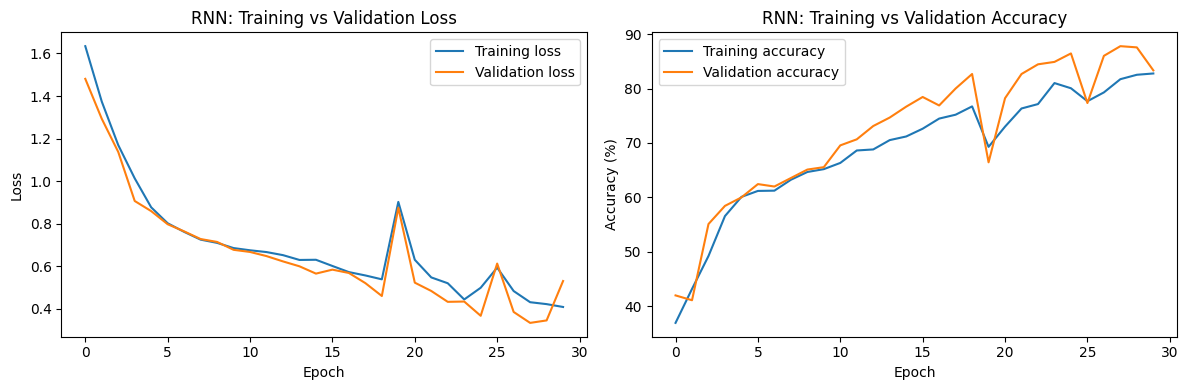

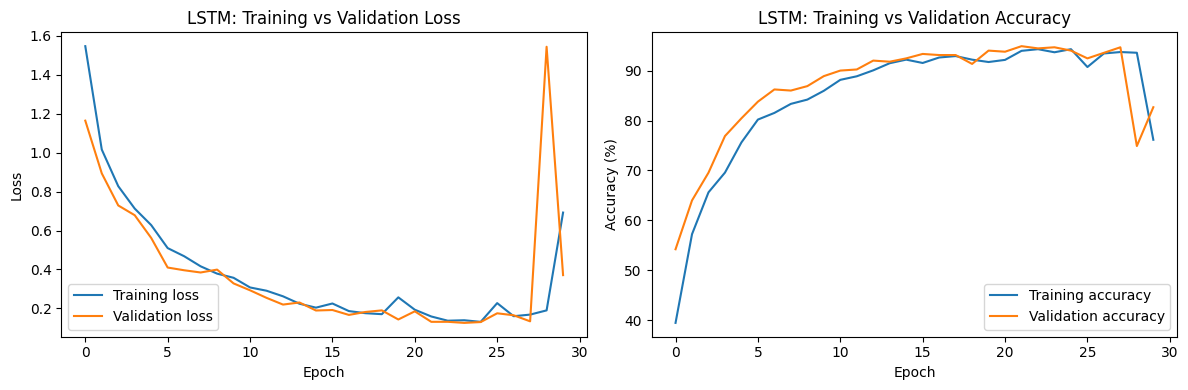

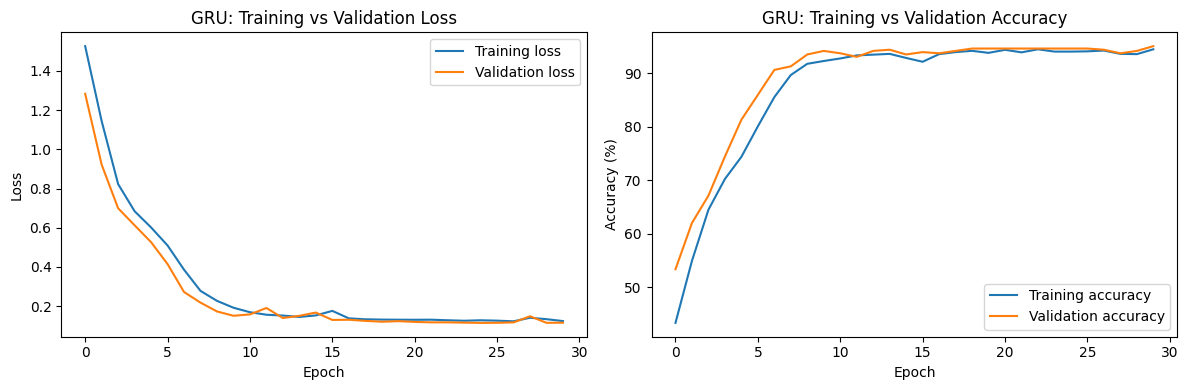

In [14]:
def plot_curves(results, model_name):
    hist = results["history"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["loss"], label="Training loss")
    axes[0].plot(hist["val_loss"], label="Validation loss")
    axes[0].set_title(f"{model_name}: Training vs Validation Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(np.array(hist["accuracy"]) * 100, label="Training accuracy")
    axes[1].plot(np.array(hist["val_accuracy"]) * 100, label="Validation accuracy")
    axes[1].set_title(f"{model_name}: Training vs Validation Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"plot23_{model_name}_curves.png", dpi=120)
    plt.show()

plot_curves(rnn_results, "RNN")
plot_curves(lstm_results, "LSTM")
plot_curves(gru_results, "GRU")


In [15]:
def summarize(results):
    return {
        "Model": results["model"],
        "Accuracy (%)": round(results["accuracy"] * 100, 2),
        "Macro Precision (%)": round(results["precision"] * 100, 2),
        "Macro Recall (%)": round(results["recall"] * 100, 2),
        "Macro F1 (%)": round(results["f1"] * 100, 2),
        "Parameters": results["params"],
        "Training Time (s)": round(results["train_time_s"], 2),
    }

perf_table = pd.DataFrame([summarize(rnn_results), summarize(lstm_results), summarize(gru_results)])
perf_table = perf_table.set_index("Model")
perf_table


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
SimpleRNN,82.67,82.74,82.67,82.30,1974,29.00
LSTM,84.67,84.86,84.67,84.31,6006,25.69
GRU,96.22,96.24,96.22,96.20,4758,22.70


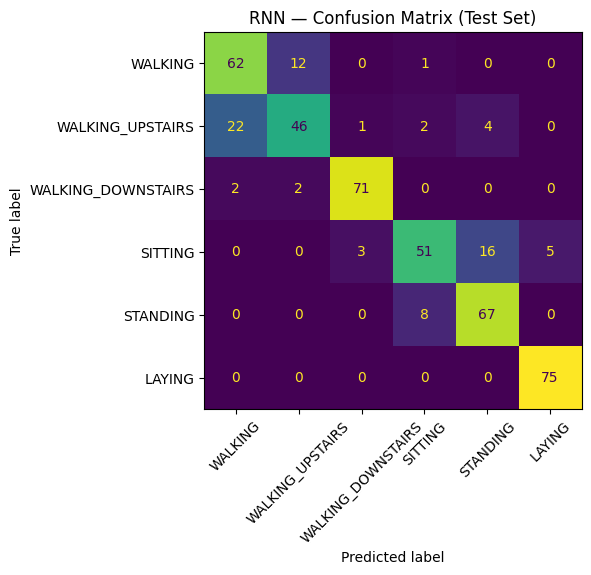

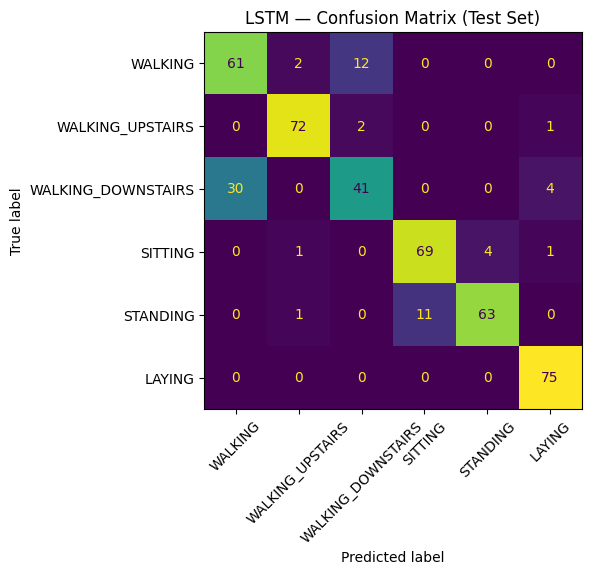

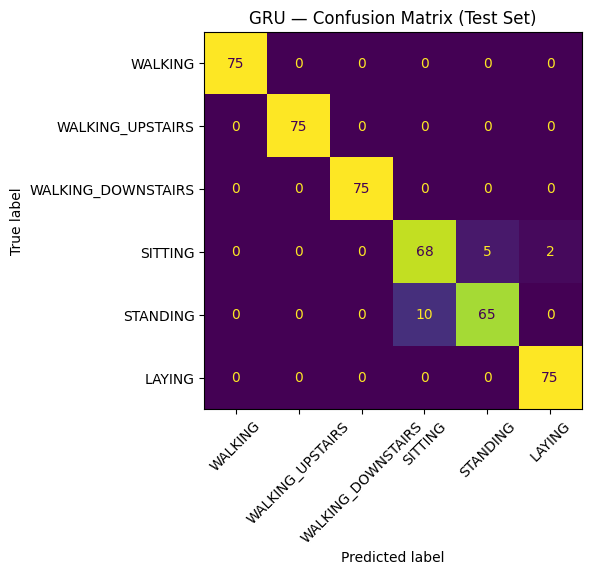

In [16]:
def plot_confusion(results, model_name):
    cm = confusion_matrix(results["y_true"], results["y_pred"])
    labels = [ACTIVITY_MAP[c+1] for c in range(NUM_CLASSES)]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{model_name} — Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.savefig(f"plot4_{model_name}_confusion.png", dpi=120)
    plt.show()
    return cm

cm_rnn  = plot_confusion(rnn_results, "RNN")
cm_lstm = plot_confusion(lstm_results, "LSTM")
cm_gru  = plot_confusion(gru_results, "GRU")


In [17]:
## 15. Confusion-matrix based analysis (automatically derived from the matrices above)
labels = [ACTIVITY_MAP[c+1] for c in range(NUM_CLASSES)]

def analyze_cm(cm, model_name):
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    best = labels[np.argmax(per_class_recall)]
    worst_idx = np.argmax(cm.sum(axis=1) - cm.diagonal())
    worst = labels[worst_idx]
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    i, j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    print(f"[{model_name}] Highest recognition rate: {best} ({per_class_recall.max()*100:.1f}%)")
    print(f"[{model_name}] Most misclassifications (total): {worst}")
    if cm_off[i, j] > 0:
        print(f"[{model_name}] Most confused pair: true={labels[i]} predicted as {labels[j]} "
              f"({cm_off[i, j]} instances)")
    print()

analyze_cm(cm_rnn, "RNN")
analyze_cm(cm_lstm, "LSTM")
analyze_cm(cm_gru, "GRU")


[RNN] Highest recognition rate: LAYING (100.0%)
[RNN] Most misclassifications (total): WALKING_UPSTAIRS
[RNN] Most confused pair: true=WALKING_UPSTAIRS predicted as WALKING (22 instances)

[LSTM] Highest recognition rate: LAYING (100.0%)
[LSTM] Most misclassifications (total): WALKING_DOWNSTAIRS
[LSTM] Most confused pair: true=WALKING_DOWNSTAIRS predicted as WALKING (30 instances)

[GRU] Highest recognition rate: WALKING (100.0%)
[GRU] Most misclassifications (total): STANDING
[GRU] Most confused pair: true=STANDING predicted as SITTING (10 instances)



In [18]:
comparison_table = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate",
                 "Update gate", "Reset gate", "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No",
             rnn_results["params"], round(rnn_results["train_time_s"],2), round(rnn_results["f1"]*100,2)],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             lstm_results["params"], round(lstm_results["train_time_s"],2), round(lstm_results["f1"]*100,2)],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes",
             gru_results["params"], round(gru_results["train_time_s"],2), round(gru_results["f1"]*100,2)],
})
comparison_table


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time (s),29.0,25.69,22.7
9,Test F1-score (%),82.3,84.31,96.2


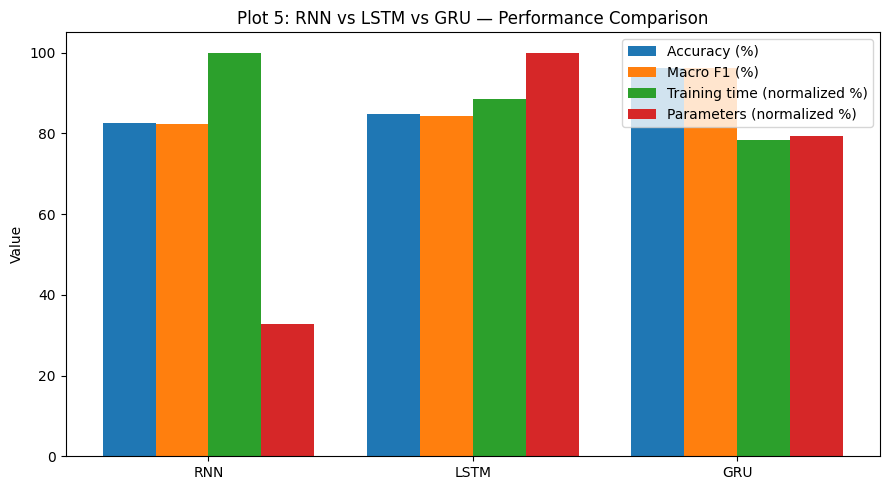

In [19]:
models_names = ["RNN", "LSTM", "GRU"]
acc_vals = [rnn_results["accuracy"]*100, lstm_results["accuracy"]*100, gru_results["accuracy"]*100]
f1_vals  = [rnn_results["f1"]*100, lstm_results["f1"]*100, gru_results["f1"]*100]
time_vals = [rnn_results["train_time_s"], lstm_results["train_time_s"], gru_results["train_time_s"]]
param_vals = [rnn_results["params"], lstm_results["params"], gru_results["params"]]

# Normalize time and params to 0-100 scale for visual comparability
time_norm = [100 * t / max(time_vals) for t in time_vals]
param_norm = [100 * p / max(param_vals) for p in param_vals]

x = np.arange(len(models_names))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 1.5*width, acc_vals, width, label="Accuracy (%)")
ax.bar(x - 0.5*width, f1_vals, width, label="Macro F1 (%)")
ax.bar(x + 0.5*width, time_norm, width, label="Training time (normalized %)")
ax.bar(x + 1.5*width, param_norm, width, label="Parameters (normalized %)")
ax.set_xticks(x); ax.set_xticklabels(models_names)
ax.set_ylabel("Value")
ax.set_title("Plot 5: RNN vs LSTM vs GRU — Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=120)
plt.show()


In [20]:
SEQ_LENS = [32, 64, 128]
seqlen_results = {}   # {T: {"RNN":f1, "LSTM":f1, "GRU":f1}}
seqlen_time = {}

for T in SEQ_LENS:
    Xtr_T = X_train_n[:, :T, :]
    Xv_T  = X_val_n[:, :T, :]
    Xte_T = X_test_n[:, :T, :]

    seqlen_results[T] = {}
    seqlen_time[T] = {}
    for rtype in ["SimpleRNN", "LSTM", "GRU"]:
        _, res = train_and_evaluate(rtype, Xtr_T, y_train, Xv_T, y_val, Xte_T, y_test, verbose=0)
        seqlen_results[T][rtype] = res["f1"] * 100
        seqlen_time[T][rtype] = res["train_time_s"]
        print(f"T={T:3d} | {rtype:9s} | F1={res['f1']*100:.2f}% | time={res['train_time_s']:.1f}s")


T= 32 | SimpleRNN | F1=81.59% | time=18.6s
T= 32 | LSTM      | F1=93.31% | time=17.7s
T= 32 | GRU       | F1=92.85% | time=17.4s
T= 64 | SimpleRNN | F1=79.43% | time=20.8s
T= 64 | LSTM      | F1=93.97% | time=19.4s
T= 64 | GRU       | F1=94.86% | time=19.8s
T=128 | SimpleRNN | F1=79.30% | time=27.9s
T=128 | LSTM      | F1=95.53% | time=22.7s
T=128 | GRU       | F1=93.95% | time=22.2s


In [21]:
seqlen_table = pd.DataFrame({
    "Sequence Length": SEQ_LENS,
    "RNN F1":  [round(seqlen_results[T]["SimpleRNN"], 2) for T in SEQ_LENS],
    "LSTM F1": [round(seqlen_results[T]["LSTM"], 2) for T in SEQ_LENS],
    "GRU F1":  [round(seqlen_results[T]["GRU"], 2) for T in SEQ_LENS],
}).set_index("Sequence Length")
seqlen_table


,RNN F1,LSTM F1,GRU F1
Sequence Length,,,
32,81.59,93.31,92.85
64,79.43,93.97,94.86
128,79.30,95.53,93.95


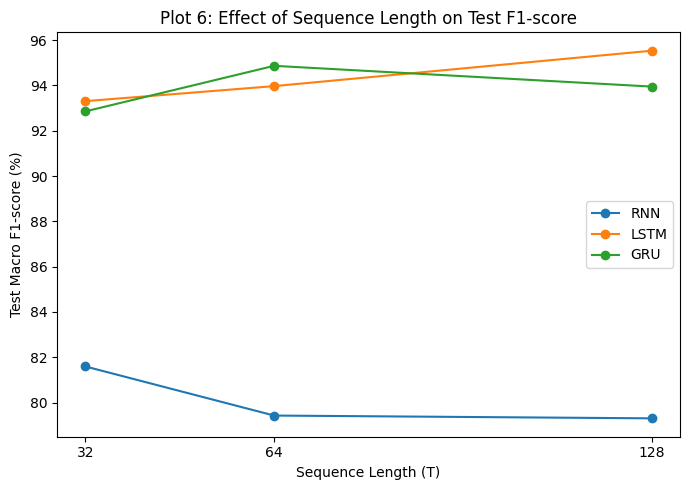

In [22]:
fig, ax = plt.subplots(figsize=(7,5))
for rtype, label in [("SimpleRNN","RNN"), ("LSTM","LSTM"), ("GRU","GRU")]:
    ax.plot(SEQ_LENS, [seqlen_results[T][rtype] for T in SEQ_LENS], marker="o", label=label)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Plot 6: Effect of Sequence Length on Test F1-score")
ax.set_xticks(SEQ_LENS)
ax.legend()
plt.tight_layout()
plt.savefig("plot6_seqlen_vs_f1.png", dpi=120)
plt.show()


In [23]:
# ---- Auto-download a small UCF101 subset (no manual dataset attachment needed) ----
# The full UCF101.rar is ~7GB, so instead of that we pull a handful of INDIVIDUAL videos,
# per class, directly from the official CRCV mirror that hosts each UCF101 clip as its own
# .avi file (the same mirror used by the official TensorFlow / TF-Hub UCF101 tutorials).
import re, ssl
from urllib import request as urlrequest

UCF_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "PlayingGuitar", "JumpRope"]  # all real UCF101 classes
VIDEOS_PER_CLASS = 8   # small number of videos per class, as recommended
N_FRAMES = 10
FRAME_SIZE = (224, 224)

UCF_MIRROR_ROOT = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
VIDEO_CACHE_DIR = os.path.join(DATA_DIR, "ucf101_videos")
os.makedirs(VIDEO_CACHE_DIR, exist_ok=True)

# The mirror's certificate is not always trusted by sandboxed notebook environments.
_unverified_ctx = ssl._create_unverified_context()

def list_ucf_mirror_videos():
    """Scrape the mirror's directory listing for all available v_ClassName_*.avi files."""
    index_html = urlrequest.urlopen(UCF_MIRROR_ROOT, context=_unverified_ctx, timeout=30).read().decode("utf-8")
    names = re.findall(r'(v_[A-Za-z0-9_]+\.avi)', index_html)
    return sorted(set(names))

def fetch_ucf_video(video_name):
    cache_path = os.path.join(VIDEO_CACHE_DIR, video_name)
    if not os.path.exists(cache_path):
        url = UCF_MIRROR_ROOT + video_name
        data = urlrequest.urlopen(url, context=_unverified_ctx, timeout=60).read()
        with open(cache_path, "wb") as f:
            f.write(data)
    return cache_path

video_paths, video_labels = [], []
try:
    all_video_names = list_ucf_mirror_videos()
    print(f"UCF101 mirror reachable — {len(all_video_names)} videos listed.")
    for cls in UCF_CLASSES:
        cls_videos = [v for v in all_video_names if v.startswith(f"v_{cls}_")][:VIDEOS_PER_CLASS]
        for v in cls_videos:
            try:
                path = fetch_ucf_video(v)
                video_paths.append(path)
                video_labels.append(cls)
            except Exception as e:
                print(f"  could not fetch {v}: {e}")
        print(f"  {cls}: downloaded {sum(1 for l in video_labels if l == cls)} videos")
    print(f"Collected {len(video_paths)} videos across {len(UCF_CLASSES)} classes.")
except Exception as e:
    print("Could not reach the UCF101 mirror directly:", e)
    print("Falling back to any UCF101 dataset attached locally on Kaggle (Add Data).")
    video_paths, video_labels = [], []


Could not reach the UCF101 mirror directly: HTTP Error 403: Forbidden
Falling back to any UCF101 dataset attached locally on Kaggle (Add Data).


In [24]:
# ---- Fallback: scan any locally attached Kaggle dataset for UCF101-style folders ----
# Only used if the direct download above collected zero videos (e.g. the mirror was
# unreachable from this network). Attach a UCF101 dataset via Kaggle's "Add Data" button;
# this scans every folder under /kaggle/input for a directory matching one of UCF_CLASSES.
if len(video_paths) == 0:
    search_roots = glob.glob("/kaggle/input/*")
    for root in search_roots:
        for cls in UCF_CLASSES:
            matches = glob.glob(os.path.join(root, "**", cls), recursive=True)
            for m in matches:
                vids = sorted(glob.glob(os.path.join(m, "*.avi")) + glob.glob(os.path.join(m, "*.mp4")))
                for v in vids[:VIDEOS_PER_CLASS]:
                    video_paths.append(v)
                    video_labels.append(cls)
    if len(video_paths) > 0:
        print(f"Recovered {len(video_paths)} videos from a locally attached Kaggle dataset.")
    else:
        print("No videos found from either the direct download or a local Kaggle dataset.")
        print("If your Kaggle session blocks crcv.ucf.edu, attach a UCF101 dataset via "
              "'Add Data' and re-run this cell (and the fetch cell above).")


Recovered 120 videos from a locally attached Kaggle dataset.


In [25]:
import cv2

def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.stack(frames[:n_frames], axis=0)  # (n_frames, H, W, 3)

print("Frame sampler ready.")


Frame sampler ready.


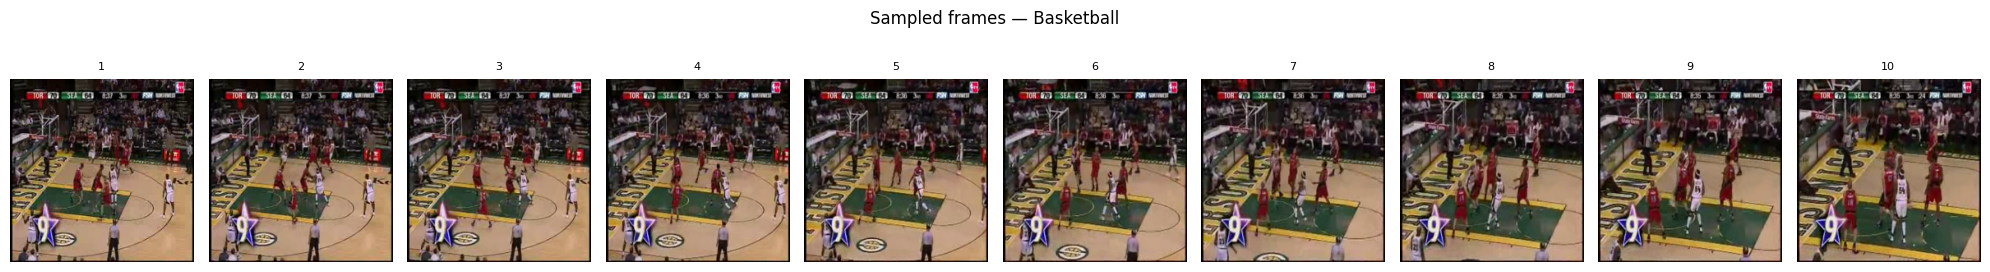

In [26]:
if len(video_paths) > 0:
    sample_video = video_paths[0]
    frames = sample_frames(sample_video)
    if frames is not None:
        fig, axes = plt.subplots(1, N_FRAMES, figsize=(20, 3))
        for i, ax in enumerate(axes):
            ax.imshow(frames[i])
            ax.axis("off")
            ax.set_title(str(i+1), fontsize=8)
        plt.suptitle(f"Sampled frames — {video_labels[0]}")
        plt.tight_layout()
        plt.savefig("plot7_video_frames.png", dpi=120)
        plt.show()
    else:
        print("Could not sample frames from", sample_video)
else:
    print("Skipping — no videos available.")


In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn_base = MobileNetV2(include_top=False, weights="imagenet",
                        input_shape=(224, 224, 3), pooling="avg")  # Global Average Pooling
cnn_base.trainable = False   # freeze pretrained CNN, do not train it

FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(frames):
    """frames: (n_frames, 224, 224, 3) uint8 -> (n_frames, D) float32"""
    x = preprocess_input(frames.astype(np.float32))
    feats = cnn_base.predict(x, verbose=0)
    return feats  # (n_frames, D)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension D = 1280


In [28]:
video_features, video_y = [], []
if len(video_paths) > 0:
    for path, label in zip(video_paths, video_labels):
        frames = sample_frames(path)
        if frames is None:
            continue
        feats = extract_video_features(frames)   # (10, D)
        video_features.append(feats)
        video_y.append(label)
    video_features = np.array(video_features)   # (num_videos, 10, D)
    print("Video feature tensor supplied to recurrent network:", video_features.shape)
else:
    video_features = np.empty((0, N_FRAMES, FEATURE_DIM))
    print("No videos processed.")


2026-09-23 10:47:25.186501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 10:47:25.322607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Video feature tensor supplied to recurrent network: (112, 10, 1280)


In [29]:
from sklearn.preprocessing import LabelEncoder

def build_video_model(recurrent_type, feature_dim, n_frames, num_classes):
    inputs = layers.Input(shape=(n_frames, feature_dim))
    RecLayer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[recurrent_type]
    x = RecLayer(32)(inputs)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

video_results = {}
if len(video_features) >= 10:   # need enough videos to split meaningfully
    le = LabelEncoder()
    y_video_enc = le.fit_transform(video_y)
    n_video_classes = len(le.classes_)

    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        video_features, y_video_enc, test_size=0.3, random_state=SEED, stratify=y_video_enc)
    Xv_tr, Xv_val, yv_tr, yv_val = train_test_split(
        Xv_tr, yv_tr, test_size=0.2, random_state=SEED, stratify=yv_tr)

    for rtype in ["LSTM", "GRU"]:
        model = build_video_model(rtype, FEATURE_DIM, N_FRAMES, n_video_classes)
        hist = model.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
                          epochs=20, batch_size=8, verbose=1)
        y_pred = np.argmax(model.predict(Xv_te, verbose=0), axis=1)
        acc = accuracy_score(yv_te, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(yv_te, y_pred, average="macro", zero_division=0)
        video_results[rtype] = {
            "model": model, "history": hist.history, "y_true": yv_te, "y_pred": y_pred,
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "params": model.count_params(), "classes": le.classes_
        }
        print(f"Video {rtype} -> Acc: {acc:.4f} | F1: {f1:.4f}")
else:
    print("Not enough video data collected to train CNN-LSTM/GRU. "
          "Attach a UCF101 dataset on Kaggle (Add Data) and re-run this section.")


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5645 - loss: 1.3246 - val_accuracy: 0.8125 - val_loss: 0.8254
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8871 - loss: 0.5839 - val_accuracy: 0.9375 - val_loss: 0.4897
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.3437 - val_accuracy: 0.8750 - val_loss: 0.3145
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.2074 - val_accuracy: 0.8750 - val_loss: 0.3045
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1667 - val_accuracy: 0.8750 - val_loss: 0.1962
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.1087 - val_accuracy: 0.8750 - val_loss: 0.2446
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0798 - val_accuracy: 0.8750 - val_loss: 0.2343
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0600 - val_accuracy: 0.9375 - val_loss: 0.1789


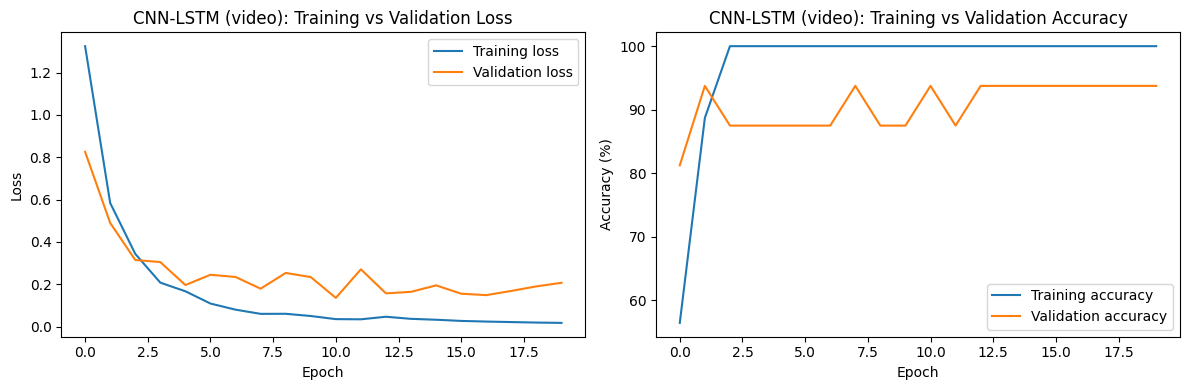

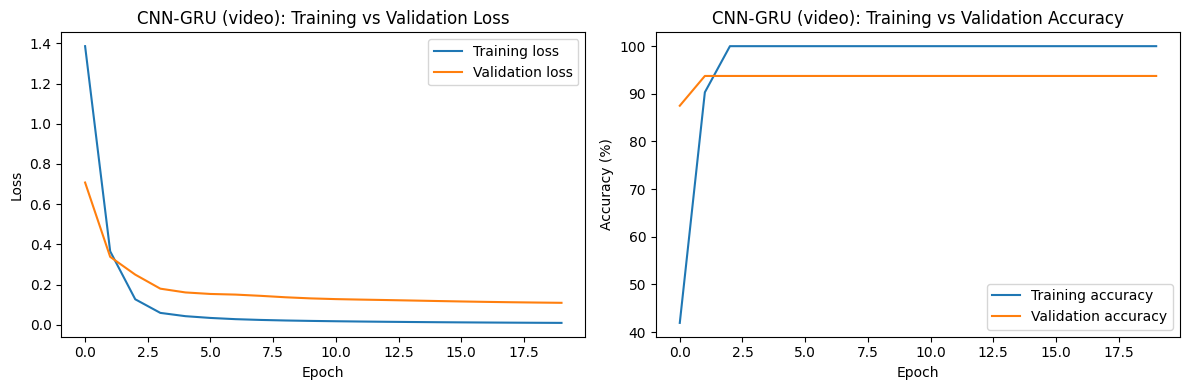

In [30]:
for rtype, res in video_results.items():
    plot_curves(res, f"CNN-{rtype} (video)")


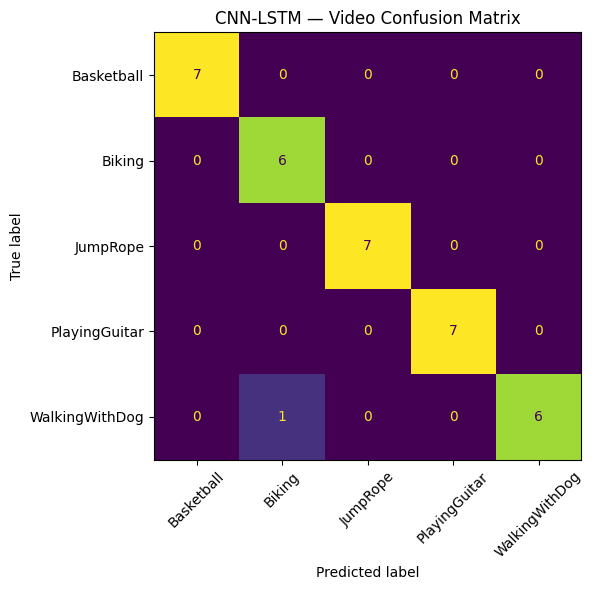

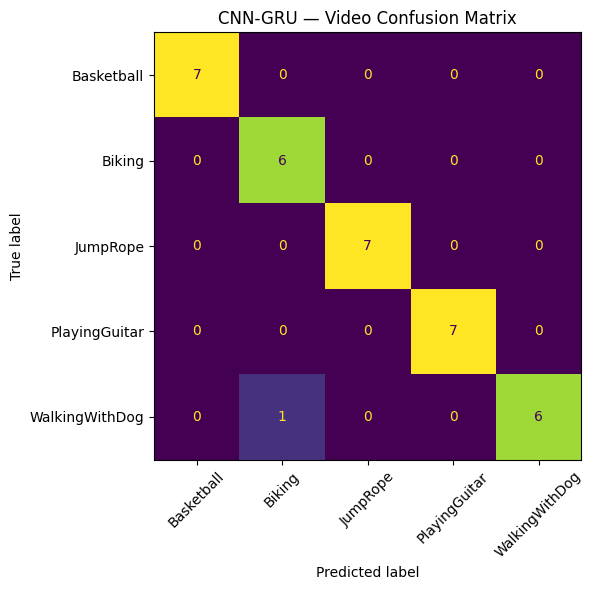

In [31]:
for rtype, res in video_results.items():
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=res["classes"])
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"CNN-{rtype} — Video Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"plot9_CNN_{rtype}_confusion.png", dpi=120)
    plt.show()


In [32]:
VOCAB_MIN, VOCAB_MAX = 1, 9      # integers used in sequences
SEQ2SEQ_LEN = 4                  # length of each sequence
NUM_SEQUENCES = 5000
START_TOKEN = 0                  # decoder start-of-sequence token
VOCAB_SIZE = VOCAB_MAX + 1        # 0..9  (0 reserved as start token)

rng2 = np.random.default_rng(SEED)

def generate_reversal_dataset(n_sequences, seq_len):
    X = rng2.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(n_sequences, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = generate_reversal_dataset(NUM_SEQUENCES, SEQ2SEQ_LEN)
print("Example:", X_seq[0], "->", Y_seq[0])

# One-hot encode for the simple encoder-decoder classifier below.
# NOTE: we deliberately do NOT use keras.utils.to_categorical here. For an input of shape
# (1, 1) (a single token at inference time) to_categorical silently squeezes the trailing
# size-1 axis and returns shape (1, V) instead of (1, 1, V), which breaks the decoder's
# Input(shape=(1, VOCAB_SIZE)) at inference. np.eye indexing preserves the input shape
# exactly and appends the vocab axis, giving (..., V) for any input shape.
def to_onehot(arr, vocab_size):
    return np.eye(vocab_size, dtype=np.float32)[arr]

X_seq_oh = to_onehot(X_seq, VOCAB_SIZE)                       # (N, T, V)
# decoder input = <START> + target shifted right (teacher forcing)
decoder_input = np.concatenate(
    [np.full((NUM_SEQUENCES, 1), START_TOKEN), Y_seq[:, :-1]], axis=1)
decoder_input_oh = to_onehot(decoder_input, VOCAB_SIZE)       # (N, T, V)
Y_seq_oh = to_onehot(Y_seq, VOCAB_SIZE)                       # (N, T, V)

(Xs_tr, Xs_te, Ds_tr, Ds_te, Ys_tr, Ys_te,
 Yraw_tr, Yraw_te, Xraw_tr, Xraw_te) = train_test_split(
    X_seq_oh, decoder_input_oh, Y_seq_oh, Y_seq, X_seq,
    test_size=0.2, random_state=SEED)
print(Xs_tr.shape, Ds_tr.shape, Ys_tr.shape)


Example: [1 7 6 4] -> [4 6 7 1]
(4000, 4, 10) (4000, 4, 10) (4000, 4, 10)


In [33]:
# ---- Encoder-Decoder LSTM (with teacher forcing) ----
LATENT_DIM = 64

encoder_inputs = layers.Input(shape=(SEQ2SEQ_LEN, VOCAB_SIZE), name="encoder_input")
encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = layers.Input(shape=(SEQ2SEQ_LEN, VOCAB_SIZE), name="decoder_input")
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = models.Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy",
                       metrics=["accuracy"])
seq2seq_model.summary()


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     19,200 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     19,200 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,050 (152.54 KB)

 Trainable params: 39,050 (152.54 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
seq2seq_history = seq2seq_model.fit(
    [Xs_tr, Ds_tr], Ys_tr, validation_split=0.1,
    epochs=40, batch_size=64, verbose=1)


Epoch 1/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2955 - loss: 2.1624 - val_accuracy: 0.3850 - val_loss: 1.8559
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4069 - loss: 1.4876 - val_accuracy: 0.4456 - val_loss: 1.2886
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4822 - loss: 1.1714 - val_accuracy: 0.5556 - val_loss: 1.0343
Epoch 4/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6820 - loss: 0.8931 - val_accuracy: 0.7894 - val_loss: 0.7462
Epoch 5/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8714 - loss: 0.5999 - val_accuracy: 0.9225 - val_loss: 0.4747
Epoch 6/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9523 - loss: 0.3761 - val_accuracy: 0.9787 - val_loss: 0.2962
Epoch 7/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.2413 - val_accuracy: 0.9956 - val_loss: 0.1968
Epoch 8/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9963 - loss: 0.1635 - val_accuracy: 0.9987 - val_loss

In [35]:
# ---- Build standalone inference encoder/decoder (no teacher forcing at test time) ----
encoder_model = models.Model(encoder_inputs, encoder_states)

decoder_state_input_h = layers.Input(shape=(LATENT_DIM,))
decoder_state_input_c = layers.Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_single_input = layers.Input(shape=(1, VOCAB_SIZE))
dec_out, dh, dc = decoder_lstm(decoder_single_input, initial_state=decoder_states_inputs)
dec_out = decoder_dense(dec_out)
decoder_model = models.Model([decoder_single_input] + decoder_states_inputs, [dec_out, dh, dc])

def predict_sequence(input_seq_onehot):
    states = encoder_model.predict(input_seq_onehot[np.newaxis, ...], verbose=0)
    target = to_onehot(np.array([[START_TOKEN]]), VOCAB_SIZE)
    output_tokens = []
    for _ in range(SEQ2SEQ_LEN):
        out, h, c = decoder_model.predict([target] + states, verbose=0)
        token = np.argmax(out[0, -1, :])
        output_tokens.append(token)
        target = to_onehot(np.array([[token]]), VOCAB_SIZE)
        states = [h, c]
    return np.array(output_tokens)


In [36]:
print(f"{'Sample':<8}{'Input Sequence':<20}{'Predicted Output':<20}")
for i in range(5):
    pred = predict_sequence(Xs_te[i])
    print(f"{i+1:<8}{str(Xraw_te[i].tolist()):<20}{str(pred.tolist()):<20}")


Sample  Input Sequence      Predicted Output    
1       [5, 3, 3, 7]        [7, 3, 3, 5]        
2       [7, 8, 9, 1]        [1, 9, 8, 7]        
3       [1, 9, 6, 3]        [3, 6, 9, 1]        
4       [2, 5, 8, 5]        [5, 8, 5, 2]        
5       [5, 8, 2, 9]        [9, 2, 8, 5]        


In [37]:
def evaluate_seq2seq(X_oh_set, y_raw_set):
    token_correct, token_total = 0, 0
    seq_correct, seq_total = 0, 0
    for i in range(len(X_oh_set)):
        pred = predict_sequence(X_oh_set[i])
        true = y_raw_set[i]
        token_correct += (pred == true).sum()
        token_total += len(true)
        seq_correct += int(np.array_equal(pred, true))
        seq_total += 1
    return token_correct / token_total, seq_correct / seq_total

token_acc, seq_acc = evaluate_seq2seq(Xs_te, Yraw_te)
final_train_loss = seq2seq_history.history["loss"][-1]
final_val_loss = seq2seq_history.history["val_loss"][-1]

print(f"Token accuracy    : {token_acc*100:.2f}%")
print(f"Sequence accuracy : {seq_acc*100:.2f}%")
print(f"Final training loss   : {final_train_loss:.4f}")
print(f"Final validation loss : {final_val_loss:.4f}")

seq2seq_metrics = pd.DataFrame([{
    "Token Accuracy (%)": round(token_acc*100, 2),
    "Sequence Accuracy (%)": round(seq_acc*100, 2),
    "Training Loss": round(final_train_loss, 4),
    "Validation Loss": round(final_val_loss, 4),
}])
seq2seq_metrics


Token accuracy    : 100.00%
Sequence accuracy : 100.00%
Final training loss   : 0.0028
Final validation loss : 0.0030


,Token Accuracy (%),Sequence Accuracy (%),Training Loss,Validation Loss
0,100.0,100.0,0.0028,0.003


In [38]:
# Pick the better of CNN-LSTM / CNN-GRU (by F1) for the consolidated table, if trained
video_row = None
if video_results:
    best_video_key = max(video_results, key=lambda k: video_results[k]["f1"])
    vres = video_results[best_video_key]
    video_row = {
        "Model": f"CNN-{best_video_key}", "Accuracy": round(vres["accuracy"]*100, 2),
        "Precision": round(vres["precision"]*100, 2), "Recall": round(vres["recall"]*100, 2),
        "F1": round(vres["f1"]*100, 2), "Parameters": vres["params"]
    }

consolidated_rows = [
    {"Model": "RNN", "Accuracy": round(rnn_results["accuracy"]*100,2),
     "Precision": round(rnn_results["precision"]*100,2), "Recall": round(rnn_results["recall"]*100,2),
     "F1": round(rnn_results["f1"]*100,2), "Parameters": rnn_results["params"]},
    {"Model": "LSTM", "Accuracy": round(lstm_results["accuracy"]*100,2),
     "Precision": round(lstm_results["precision"]*100,2), "Recall": round(lstm_results["recall"]*100,2),
     "F1": round(lstm_results["f1"]*100,2), "Parameters": lstm_results["params"]},
    {"Model": "GRU", "Accuracy": round(gru_results["accuracy"]*100,2),
     "Precision": round(gru_results["precision"]*100,2), "Recall": round(gru_results["recall"]*100,2),
     "F1": round(gru_results["f1"]*100,2), "Parameters": gru_results["params"]},
]
if video_row is not None:
    consolidated_rows.append(video_row)

consolidated_table = pd.DataFrame(consolidated_rows).set_index("Model")
consolidated_table


,Accuracy,Precision,Recall,F1,Parameters
Model,,,,,
RNN,82.67,82.74,82.67,82.30,1974
LSTM,84.67,84.86,84.67,84.31,6006
GRU,96.22,96.24,96.22,96.20,4758
CNN-LSTM,97.06,97.14,97.14,96.92,168229


In [39]:
seq2seq_table_final = pd.DataFrame([{
    "Task": "Seq2Seq Reversal",
    "Token Accuracy (%)": round(token_acc*100, 2),
    "Sequence Accuracy (%)": round(seq_acc*100, 2),
    "Training Loss": round(final_train_loss, 4),
    "Validation Loss": round(final_val_loss, 4),
}]).set_index("Task")
seq2seq_table_final


,Token Accuracy (%),Sequence Accuracy (%),Training Loss,Validation Loss
Task,,,,
Seq2Seq Reversal,100.0,100.0,0.0028,0.003


In [40]:
unit_variants = [16, 32, 64]
ex1_rows = []
for u in unit_variants:
    _, res = train_and_evaluate("SimpleRNN", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test,
                                 verbose=0, units=u)
    ex1_rows.append({"Units": u, "Accuracy (%)": round(res["accuracy"]*100,2),
                      "F1 (%)": round(res["f1"]*100,2), "Parameters": res["params"],
                      "Training Time (s)": round(res["train_time_s"],2)})
ex1_table = pd.DataFrame(ex1_rows).set_index("Units")
ex1_table


,Accuracy (%),F1 (%),Parameters,Training Time (s)
Units,,,,
16,71.11,70.86,790,27.43
32,77.33,77.20,1974,27.58
64,84.44,84.28,5878,28.46


In [41]:
print("Already compared with identical units (32) in Sections 10-16:")
print(f"LSTM -> Acc: {lstm_results['accuracy']*100:.2f}%  F1: {lstm_results['f1']*100:.2f}%  "
      f"Params: {lstm_results['params']}  Time: {lstm_results['train_time_s']:.1f}s")
print(f"GRU  -> Acc: {gru_results['accuracy']*100:.2f}%  F1: {gru_results['f1']*100:.2f}%  "
      f"Params: {gru_results['params']}  Time: {gru_results['train_time_s']:.1f}s")


Already compared with identical units (32) in Sections 10-16:
LSTM -> Acc: 84.67%  F1: 84.31%  Params: 6006  Time: 25.7s
GRU  -> Acc: 96.22%  F1: 96.20%  Params: 4758  Time: 22.7s


In [42]:
ex3_rows = []
for rtype in ["SimpleRNN", "LSTM", "GRU"]:
    _, res = train_and_evaluate(rtype, X_train_n, y_train, X_val_n, y_val, X_test_n, y_test,
                                 verbose=0, extra_layer=True)
    ex3_rows.append({"Model": rtype, "Accuracy (%)": round(res["accuracy"]*100,2),
                      "F1 (%)": round(res["f1"]*100,2), "Parameters": res["params"],
                      "Training Time (s)": round(res["train_time_s"],2)})
ex3_table = pd.DataFrame(ex3_rows).set_index("Model")
print("Single-layer results (for reference):")
print(perf_table[["Accuracy (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]])
print("\nTwo-layer (stacked) results:")
ex3_table


Single-layer results (for reference):
           Accuracy (%)  Macro F1 (%)  Parameters  Training Time (s)
Model                                                               
SimpleRNN         82.67         82.30        1974              29.00
LSTM              84.67         84.31        6006              25.69
GRU               96.22         96.20        4758              22.70

Two-layer (stacked) results:


,Accuracy (%),F1 (%),Parameters,Training Time (s)
Model,,,,
SimpleRNN,77.33,77.00,4054,44.87
LSTM,94.67,94.64,14326,32.32
GRU,96.22,96.21,11094,31.50


In [43]:
_, uni_res = train_and_evaluate("LSTM", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test,
                                 verbose=0, bidirectional=False)
_, bi_res  = train_and_evaluate("LSTM", X_train_n, y_train, X_val_n, y_val, X_test_n, y_test,
                                 verbose=0, bidirectional=True)

ex4_table = pd.DataFrame([
    {"Variant": "Unidirectional LSTM", "Accuracy (%)": round(uni_res["accuracy"]*100,2),
     "F1 (%)": round(uni_res["f1"]*100,2), "Parameters": uni_res["params"],
     "Training Time (s)": round(uni_res["train_time_s"],2)},
    {"Variant": "Bidirectional LSTM", "Accuracy (%)": round(bi_res["accuracy"]*100,2),
     "F1 (%)": round(bi_res["f1"]*100,2), "Parameters": bi_res["params"],
     "Training Time (s)": round(bi_res["train_time_s"],2)},
]).set_index("Variant")
ex4_table


,Accuracy (%),F1 (%),Parameters,Training Time (s)
Variant,,,,
Unidirectional LSTM,94.89,94.87,6006,22.96
Bidirectional LSTM,94.00,93.92,11894,32.06


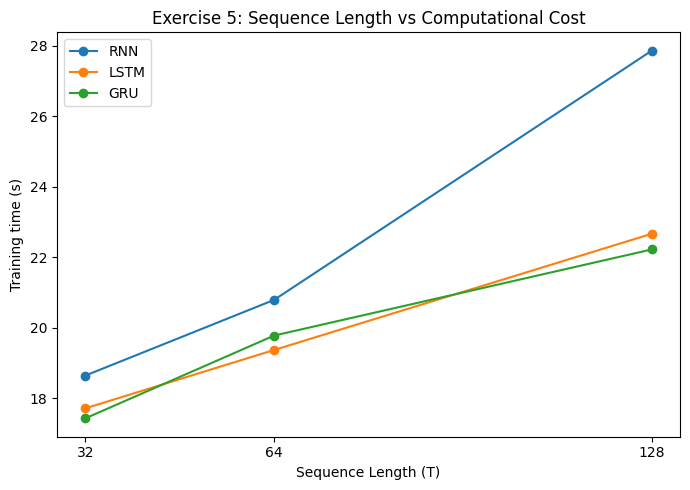

In [44]:
fig, ax = plt.subplots(figsize=(7,5))
for rtype, label in [("SimpleRNN","RNN"), ("LSTM","LSTM"), ("GRU","GRU")]:
    ax.plot(SEQ_LENS, [seqlen_time[T][rtype] for T in SEQ_LENS], marker="o", label=label)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Training time (s)")
ax.set_title("Exercise 5: Sequence Length vs Computational Cost")
ax.set_xticks(SEQ_LENS)
ax.legend()
plt.tight_layout()
plt.savefig("ex5_seqlen_vs_time.png", dpi=120)
plt.show()


In [45]:
if video_results:
    ex6_rows = []
    for rtype, res in video_results.items():
        ex6_rows.append({"Model": f"CNN-{rtype}", "Accuracy (%)": round(res["accuracy"]*100,2),
                          "F1 (%)": round(res["f1"]*100,2), "Parameters": res["params"]})
    ex6_table = pd.DataFrame(ex6_rows).set_index("Model")
    ex6_table
else:
    print("Run Section 18-21 with a UCF101 dataset attached to populate this comparison "
          "(both CNN-LSTM and CNN-GRU are trained on the exact same extracted CNN features).")


In [46]:
# Task: input length 5, output length = only the first 3 elements, reversed
IN_LEN, OUT_LEN = 5, 3
NUM_SEQ_EX7 = 5000

def generate_variable_length_dataset(n, in_len, out_len):
    X = rng2.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(n, in_len))
    Y = X[:, :out_len][:, ::-1]   # reverse only the first `out_len` elements
    return X, Y

X7, Y7 = generate_variable_length_dataset(NUM_SEQ_EX7, IN_LEN, OUT_LEN)
print("Example:", X7[0], "-> (reverse of first", OUT_LEN, "elements) ->", Y7[0])

X7_oh = to_onehot(X7, VOCAB_SIZE)
dec_in7 = np.concatenate([np.full((NUM_SEQ_EX7, 1), START_TOKEN), Y7[:, :-1]], axis=1)
dec_in7_oh = to_onehot(dec_in7, VOCAB_SIZE)
Y7_oh = to_onehot(Y7, VOCAB_SIZE)

(X7_tr, X7_te, D7_tr, D7_te, Y7_tr, Y7_te, Y7raw_tr, Y7raw_te) = train_test_split(
    X7_oh, dec_in7_oh, Y7_oh, Y7, test_size=0.2, random_state=SEED)

enc_in7 = layers.Input(shape=(IN_LEN, VOCAB_SIZE))
enc_lstm7 = layers.LSTM(LATENT_DIM, return_state=True)
_, h7, c7 = enc_lstm7(enc_in7)

dec_in7_layer = layers.Input(shape=(OUT_LEN, VOCAB_SIZE))
dec_lstm7 = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_out7, _, _ = dec_lstm7(dec_in7_layer, initial_state=[h7, c7])
dec_dense7 = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_out7 = dec_dense7(dec_out7)

model7 = models.Model([enc_in7, dec_in7_layer], dec_out7)
model7.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model7.fit([X7_tr, D7_tr], Y7_tr, validation_split=0.1, epochs=40, batch_size=64, verbose=1)


Example: [1 7 2 7 6] -> (reverse of first 3 elements) -> [2 7 1]
Epoch 1/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2637 - loss: 2.1641 - val_accuracy: 0.3608 - val_loss: 1.8237
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4298 - loss: 1.4436 - val_accuracy: 0.4775 - val_loss: 1.2056
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4755 - loss: 1.1385 - val_accuracy: 0.5008 - val_loss: 1.0661
Epoch 4/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5153 - loss: 1.0114 - val_accuracy: 0.5608 - val_loss: 0.9527
Epoch 5/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5619 - loss: 0.9057 - val_accuracy: 0.6108 - val_loss: 0.8506
Epoch 6/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6286 - loss: 0.8050 - val_accuracy: 0.6633 - val_loss: 0.7483
Epoch 7/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7064 - loss: 0.6982 - val_accuracy: 0.7292 - val_loss: 0.6397
Epoch 8/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

In [47]:
encoder_model7 = models.Model(enc_in7, [h7, c7])
dec_state_h7 = layers.Input(shape=(LATENT_DIM,))
dec_state_c7 = layers.Input(shape=(LATENT_DIM,))
dec_single_in7 = layers.Input(shape=(1, VOCAB_SIZE))
o7, hh7, cc7 = dec_lstm7(dec_single_in7, initial_state=[dec_state_h7, dec_state_c7])
o7 = dec_dense7(o7)
decoder_model7 = models.Model([dec_single_in7, dec_state_h7, dec_state_c7], [o7, hh7, cc7])

def predict_sequence7(input_seq_onehot, out_len=OUT_LEN):
    h, c = encoder_model7.predict(input_seq_onehot[np.newaxis, ...], verbose=0)
    target = to_onehot(np.array([[START_TOKEN]]), VOCAB_SIZE)
    out_tokens = []
    for _ in range(out_len):
        out, h, c = decoder_model7.predict([target, h, c], verbose=0)
        token = np.argmax(out[0, -1, :])
        out_tokens.append(token)
        target = to_onehot(np.array([[token]]), VOCAB_SIZE)
    return np.array(out_tokens)

print(f"{'Sample':<8}{'Input (len 5)':<20}{'Predicted Output (len 3)':<25}")
for i in range(5):
    pred7 = predict_sequence7(X7_te[i])
    print(f"{i+1:<8}{str(np.argmax(X7_te[i],axis=-1).tolist()):<20}{str(pred7.tolist()):<25}")

tok_acc7, seq_acc7 = 0, 0
tot_tok7, tot_seq7 = 0, 0
for i in range(len(X7_te)):
    pred7 = predict_sequence7(X7_te[i])
    tok_acc7 += (pred7 == Y7raw_te[i]).sum(); tot_tok7 += OUT_LEN
    seq_acc7 += int(np.array_equal(pred7, Y7raw_te[i])); tot_seq7 += 1
print(f"\nToken accuracy: {tok_acc7/tot_tok7*100:.2f}%  |  Sequence accuracy: {seq_acc7/tot_seq7*100:.2f}%")


Sample  Input (len 5)       Predicted Output (len 3) 
1       [9, 8, 1, 5, 3]     [1, 8, 9]                
2       [7, 7, 2, 7, 7]     [2, 7, 7]                
3       [1, 6, 2, 8, 6]     [2, 6, 1]                
4       [8, 7, 5, 1, 5]     [5, 7, 8]                
5       [1, 9, 2, 2, 9]     [2, 9, 1]                

Token accuracy: 99.90%  |  Sequence accuracy: 99.90%
